In [1]:
# Imports
import os
import wandb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from pathlib import Path
from wandb.integration.keras import WandbMetricsLogger, WandbModelCheckpoint

import Dataset
from model import get_model, bce_dice_loss, dice_coefficient

2026-03-25 15:37:52.799991: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-25 15:37:53.230959: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-25 15:37:53.231085: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-25 15:37:53.305039: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-25 15:37:53.440752: I tensorflow/core/platform/cpu_feature_guar

In [2]:
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


2026-03-25 15:37:57.072600: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-03-25 15:37:57.299083: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-03-25 15:37:57.299145: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.


In [3]:
# ── Experiment config ──────────────────────────────────────────────────────
# Change MODEL_NAME to switch experiments. Available options:
#   'unet'                     — baseline
#   'deeplabv3plus_pretrained' | 'deeplabv3plus_scratch'
#   'segformer_pretrained'     | 'segformer_scratch'
#   'yolo_pretrained'          | 'yolo_scratch'

MODEL_NAME  = 'unet'
EPOCHS      = 30
LR          = 1e-4
FREEZE_EPOCHS = 5   # epochs to train with backbone frozen (pretrained models only)

# ── Paths ───────────────────────────────────────────────────────────────────
CSV_PATH  = Path('train.csv')
TRAIN_DIR = Path('train_images')
TEST_DIR  = Path('test_images')
SAVE_DIR  = Path('saved_models')

In [ ]:
train_data, val_data = Dataset.parse_csv(str(CSV_PATH))

train_ds = Dataset.build_dataset(train_data, 'train_images/', shuffle=True)
val_ds   = Dataset.build_dataset(val_data,   'train_images/', shuffle=False)

# Verify
for images, masks in train_ds.take(1):
    print(images.shape)  # (16, 256, 256, 3)
    print(masks.shape)   # (16, 256, 256, 4)

2026-03-25 15:38:09.112325: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-03-25 15:38:09.112444: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-03-25 15:38:09.112472: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-03-25 15:38:09.297339: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-03-25 15:38:09.297427: I external/local_xla/xla/stream_executor

(8, 256, 256, 3)
(8, 256, 256, 4)


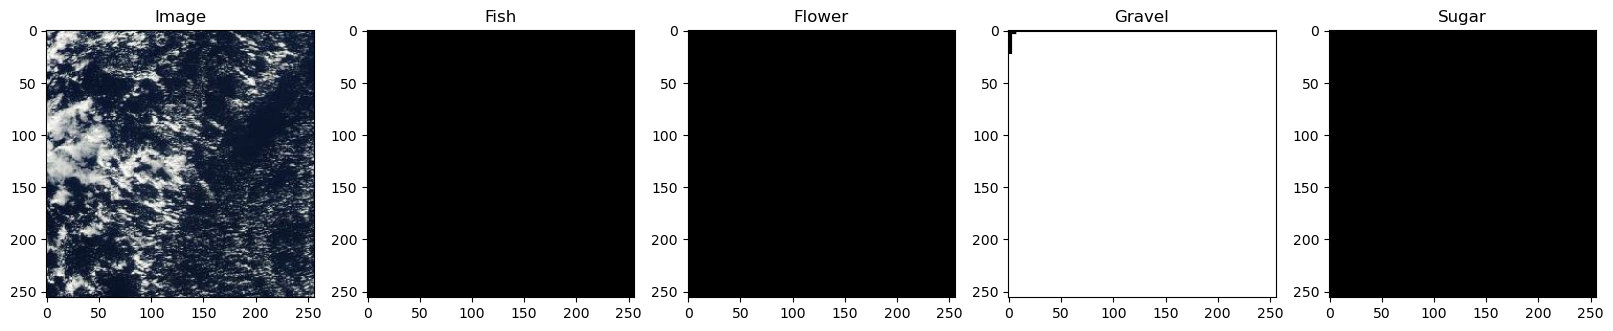

In [5]:
for images, masks in train_ds.take(1):
    fig, axes = plt.subplots(1, 5, figsize=(20, 4))
    
    axes[0].imshow(images[0].numpy())
    axes[0].set_title('Image')
    
    for i, class_name in enumerate(Dataset.CLASSES):
        axes[i+1].imshow(masks[0, :, :, i].numpy(), cmap='gray')
        axes[i+1].set_title(class_name)
    
    plt.show()

In [6]:
# ── W&B init ────────────────────────────────────────────────────────────────
import os
from dotenv import load_dotenv
load_dotenv()  # loads WANDB_API_KEY from .env file

os.environ['WANDB_API_KEY'] = os.environ['WANDB_API_KEY']  # ensure it's set for the process

run = wandb.init(
    project = 'cubesat-cloud-seg',
    name    = MODEL_NAME,
    config  = {
        'model':          MODEL_NAME,
        'epochs':         EPOCHS,
        'learning_rate':  LR,
        'batch_size':     Dataset.BATCH_SIZE,
        'img_size':       Dataset.IMG_SIZE,
        'num_classes':    Dataset.NUM_CLASSES,
        'classes':        Dataset.CLASSES,
        'freeze_epochs':  FREEZE_EPOCHS,
        'loss':           'bce_dice',
    },
    tags = [MODEL_NAME, 'semantic-seg'],
)
print(f"W&B run: {run.url}")

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: jason-simental03 (jason-simental03-colorado-state-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


W&B run: https://wandb.ai/jason-simental03-colorado-state-university/cubesat-cloud-seg/runs/wg8mc4xv


In [7]:
# ── Build & compile model ────────────────────────────────────────────────────
model = get_model(MODEL_NAME)
model.summary()






IS_PRETRAINED = 'pretrained' in MODEL_NAME

# For pretrained models: freeze backbone first, then unfreeze for fine-tuning
if IS_PRETRAINED:
    for layer in model.layers:
        if hasattr(layer, 'layers'):   # sub-model (the backbone)
            layer.trainable = False
    print(f"Backbone frozen for first {FREEZE_EPOCHS} epoch(s).")

model.compile(
    optimizer = tf.keras.optimizers.Adam(LR),
    loss      = bce_dice_loss,
    metrics   = [dice_coefficient],
)

Model: "unet_scratch"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input (InputLayer)          [(None, 256, 384, 3)]        0         []                            
                                                                                                  
 conv2d (Conv2D)             (None, 256, 384, 32)         864       ['input[0][0]']               
                                                                                                  
 batch_normalization (Batch  (None, 256, 384, 32)         128       ['conv2d[0][0]']              
 Normalization)                                                                                   
                                                                                                  
 re_lu (ReLU)                (None, 256, 384, 32)         0         ['batch_normalizati

In [8]:
# ── Callbacks ────────────────────────────────────────────────────────────────
ckpt_path = str(SAVE_DIR / f'{MODEL_NAME}_best.keras')

callbacks = [
    # Log metrics to W&B every epoch
    WandbMetricsLogger(log_freq='epoch'),

    # Save best checkpoint to W&B
    WandbModelCheckpoint(
        filepath        = ckpt_path,
        monitor         = 'val_dice_coefficient',
        mode            = 'max',
        save_best_only  = True,
        verbose         = 1,
    ),

    # Stop early if val Dice stops improving
    tf.keras.callbacks.EarlyStopping(
        monitor              = 'val_dice_coefficient',
        patience             = 7,
        mode                 = 'max',
        restore_best_weights = True,
        verbose              = 1,
    ),

    # Reduce LR on plateau
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor  = 'val_dice_coefficient',
        factor   = 0.5,
        patience = 3,
        mode     = 'max',
        min_lr   = 1e-7,
        verbose  = 1,
    ),
]

wandb: WARNING When using `save_best_only`, ensure that the `filepath` argument contains formatting placeholders like `{epoch:02d}` or `{batch:02d}`. This ensures correct interpretation of the logged artifacts.


In [9]:
# ── Training ─────────────────────────────────────────────────────────────────
# Phase 1: frozen backbone (pretrained models) or full training (scratch models)
history = model.fit(
    train_ds,
    validation_data = val_ds,
    epochs          = FREEZE_EPOCHS if IS_PRETRAINED else EPOCHS,
    callbacks       = callbacks,
)

# Phase 2: unfreeze backbone and fine-tune at lower LR
if IS_PRETRAINED:
    print("\nUnfreezing backbone for fine-tuning...")
    for layer in model.layers:
        layer.trainable = True

    model.compile(
        optimizer = tf.keras.optimizers.Adam(LR / 10),
        loss      = bce_dice_loss,
        metrics   = [dice_coefficient],
    )

    history_ft = model.fit(
        train_ds,
        validation_data = val_ds,
        epochs          = EPOCHS,
        initial_epoch   = FREEZE_EPOCHS,
        callbacks       = callbacks,
    )

Epoch 1/30


2026-03-09 17:35:46.997239: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8904
2026-03-09 17:35:47.362662: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2026-03-09 17:35:56.182290: I external/local_xla/xla/service/service.cc:168] XLA service 0x7edb42828b50 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-03-09 17:35:56.182330: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9
2026-03-09 17:35:56.192955: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1773099356.289402    2100 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
2026-03-09 17:36:01.023014: W extern

616/617 [============================>.] - ETA: 0s - loss: 1.2643 - dice_coefficient: 0.2900

2026-03-09 17:45:43.889870: W external/local_tsl/tsl/framework/bfc_allocator.cc:296] Allocator (GPU_0_bfc) ran out of memory trying to allocate 6.20GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2026-03-09 17:45:46.324407: W external/local_tsl/tsl/framework/bfc_allocator.cc:296] Allocator (GPU_0_bfc) ran out of memory trying to allocate 6.20GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.


617/617 [==============================] - ETA: 0s - loss: 1.2643 - dice_coefficient: 0.2897
Epoch 1: val_dice_coefficient improved from -inf to 0.35948, saving model to saved_models/unet_best.keras
617/617 [==============================] - 676s 1s/step - loss: 1.2643 - dice_coefficient: 0.2897 - val_loss: 1.1904 - val_dice_coefficient: 0.3595 - lr: 1.0000e-04
Epoch 2/30
617/617 [==============================] - ETA: 0s - loss: 1.1247 - dice_coefficient: 0.3699
Epoch 2: val_dice_coefficient improved from 0.35948 to 0.42347, saving model to saved_models/unet_best.keras
617/617 [==============================] - 609s 984ms/step - loss: 1.1247 - dice_coefficient: 0.3699 - val_loss: 1.1501 - val_dice_coefficient: 0.4235 - lr: 1.0000e-04
Epoch 3/30
617/617 [==============================] - ETA: 0s - loss: 1.0803 - dice_coefficient: 0.4023
Epoch 3: val_dice_coefficient improved from 0.42347 to 0.44652, saving model to saved_models/unet_best.keras
617/617 [==============================] -

KeyboardInterrupt: 

Error in callback <bound method _WandbInit._post_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x7edd724cd360>> (for post_run_cell), with arguments args (<ExecutionResult object at 7edd1c2dc430, execution_count=9 error_before_exec=None error_in_exec= info=<ExecutionInfo object at 7edd1c2df550, raw_cell="# ── Training ────────────────────────────────────.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell://wsl%2Bubuntu/home/jason/CubeSAT_Payload/training.ipynb#X11sdnNjb2RlLXJlbW90ZQ%3D%3D> result=None>,),kwargs {}:


ConnectionResetError: Connection lost

In [ ]:
# ── Per-class Dice evaluation ─────────────────────────────────────────────────
print("\nValidation Dice per class:")
all_true, all_pred = [], []

for images, masks in val_ds:
    preds = model(images, training=False)
    all_true.append(masks.numpy())
    all_pred.append(preds.numpy())

all_true = np.concatenate(all_true, axis=0)
all_pred = np.concatenate(all_pred, axis=0)

per_class_dice = {}
for i, cls in enumerate(Dataset.CLASSES):
    yt = all_true[..., i]
    yp = (all_pred[..., i] > 0.5).astype(np.float32)
    intersection = (yt * yp).sum()
    union        = yt.sum() + yp.sum()
    dice         = (2 * intersection + 1e-6) / (union + 1e-6)
    per_class_dice[cls] = float(dice)
    print(f"  {cls:10s}: {dice:.4f}")

mean_dice = np.mean(list(per_class_dice.values()))
print(f"\n  Mean Dice : {mean_dice:.4f}")

# Log per-class results to W&B
wandb.log({f'val_dice_{k}': v for k, v in per_class_dice.items()})
wandb.log({'val_mean_dice': mean_dice})

# Quick visual check on one validation batch
images, masks = next(iter(val_ds))
preds = model(images[:1], training=False).numpy()

fig, axes = plt.subplots(3, Dataset.NUM_CLASSES, figsize=(16, 9))
for i, cls in enumerate(Dataset.CLASSES):
    axes[0, i].imshow(images[0].numpy()); axes[0, i].set_title(f'Image')
    axes[1, i].imshow(masks[0, :, :, i].numpy(), cmap='gray'); axes[1, i].set_title(f'GT: {cls}')
    axes[2, i].imshow(preds[0, :, :, i] > 0.5,  cmap='gray'); axes[2, i].set_title(f'Pred: {cls}')
[ax.axis('off') for ax in axes.ravel()]
plt.tight_layout()
wandb.log({'val_predictions': wandb.Image(fig)})
plt.show()

In [ ]:
# ── TFLite export (FP16) ──────────────────────────────────────────────────────
tflite_path = str(SAVE_DIR / f'{MODEL_NAME}_fp16.tflite')

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations         = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_types = [tf.float16]

tflite_model = converter.convert()

with open(tflite_path, 'wb') as f:
    f.write(tflite_model)

size_mb = os.path.getsize(tflite_path) / 1e6
print(f"TFLite model saved → {tflite_path}  ({size_mb:.1f} MB)")

# Log the .tflite file as a W&B artifact
artifact = wandb.Artifact(name=f'{MODEL_NAME}-tflite', type='model')
artifact.add_file(tflite_path)
run.log_artifact(artifact)

# Quick inference sanity check with TFLite interpreter
interpreter = tf.lite.Interpreter(model_path=tflite_path)
interpreter.allocate_tensors()

inp_details  = interpreter.get_input_details()
out_details  = interpreter.get_output_details()

sample = images[:1].numpy().astype(np.float32)
interpreter.set_tensor(inp_details[0]['index'], sample)
interpreter.invoke()
tflite_out = interpreter.get_tensor(out_details[0]['index'])
print(f"TFLite output shape : {tflite_out.shape}")
print(f"Output range        : [{tflite_out.min():.3f}, {tflite_out.max():.3f}]")

In [ ]:
# ── Finish W&B run ────────────────────────────────────────────────────────────
wandb.finish()